**NOTE:** For all questions in this notebook, include your answers in the write pdf submission. Do **not** submit the colab.

# Homework 2

We will use the CIFAR-100 in this notebook, which has **100** classes. Unlike homework 1, we will instead use CNN models to investigate some interesting aspects of training deep models. Moreover, we will use standard PyTorch `nn.Module`s and `optim.Optimizer`s.

<h2>CIFAR-100</h2>

CIFAR-100  is a image classification dataset.
+ Each data sample is an RGB $32\times32$ real image. A raw loaded image $\in \mathbb{R}^{3 \times 32 \times 32}$.
+ Each image is associated with a label $\in \{0,1,2,\dots, 99\}$.


Our goal is to train a neural network classifier that takes such $3\times32\times32$ images and predict a label $\in \{0, 1, 2, \dots, 99\}$.

In [1]:
from sklearn.externals.array_api_compat import torch

from utilties.utils import func_train_test_val_split

# install dependencies

You should run on GPU-enabled colab server (should be default for this notebook).

In [2]:
from typing import *

import matplotlib.pyplot as plt
import seaborn as sns
import dataclasses
from tqdm.auto import tqdm
import numpy as np

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.utils import make_grid
import torchvision
from torch.utils.data import DataLoader

assert torch.mps.is_available(), "Should use GPU-enabled colab"

device = torch.device("mps")  # we will train with MPS!

## Hyperparameter transfer (6pt)
The year is 2028. The evil large language model Megatron has usurped the stewardship of
the corporation known as OpenAI and is wreaking havoc upon B2B SaaS all across Silicon
Valley. You are Geoffrey Hinton: leader of the resistance. You plan to train your own
large language model to infiltrate the OpenAI offices, disable the large language model
Megatron and restore order to the Valley.
But there’s a problem: the resistance doesn’t have enough cloud credits to tune all the
hyperparameters of the large language model. In this homework problem, we will learn
how to do hyperparameter transfer, which lets us tune hyperparameters on a small network
and transfer them to a larger network, avoiding the costly process of tuning the large
network. In particular, we will learn how to initialise and update the weights of a neural
network in a way that scales well as we increase the network width.

# Dataset

Let's reuse the homework 1 augmented dataset code, but now modified to work on **CIFAR-100**. Code is hidden in the cell below, but make sure to still run it.

In [3]:
# @title


def get_datasets(train_transforms=(), val_transforms=()):
    r"""
    Returns the CIFAR-100 training and validation datasets with corresponding
    transforms.

    `*_transforms` represent optional transformations, e.g., conversion to
    PyTorch tensors, preprocessing, etc.
    """
    train_set = torchvision.datasets.CIFAR100(
        "./data",
        train=True,
        download=True,
        transform=torchvision.transforms.Compose(train_transforms),
    )
    val_set = torchvision.datasets.CIFAR100(
        "./data",
        train=False,
        download=True,
        transform=torchvision.transforms.Compose(val_transforms),
    )
    return train_set, val_set


cifar100_mean = torch.as_tensor([0.5071, 0.4865, 0.4409])
cifar100_std = torch.as_tensor([0.2673, 0.2564, 0.2762])

train_transforms = [
    torchvision.transforms.RandomCrop(32, padding=3, padding_mode="reflect"),
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=cifar100_mean, std=cifar100_std),
]

val_transforms = [
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=cifar100_mean, std=cifar100_std),
]

# Network Definition

**Question 5**: Implement the following function that creates the specified CNN networks. Read through the docstring and make sure that your implementation behaves as required. Afterwards, print the outputs of
+ `make_cnn(100, 'tanh', num_conv_layers=5, num_fc_layers=4)`
+ `make_cnn(3, 'none', num_conv_layers=3, num_fc_layers=2)`

Add both your implementation and outputs to the writeup.

---

Links you may find useful:
+ `none` activation: https://pytorch.org/docs/stable/generated/torch.nn.Identity.html?highlight=identity#torch.nn.Identity
+ Chaining layers: https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html?highlight=sequential#torch.nn.Sequential
+ Reshaping image-like tensors to vectors: https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html?highlight=flatten#torch.nn.Flatten

(You are not required to use these classes)

In [4]:
def make_mlp(
    num_inputs: int, num_outputs: int, activation: Any = None, hidden_sizes: int = [128]
) -> nn.Module:

    if activation == "relu":
        act_cls = nn.ReLU
    elif activation == "tanh":
        act_cls = nn.Tanh
    elif activation == "none" or not activation:
        act_cls = nn.Identity
    else:
        raise ValueError(f"Unexpected activation={repr(activation)}")

    net = [nn.Flatten(), nn.Linear(num_inputs, hidden_sizes[0]), act_cls()]

    for i in range(1, len(hidden_sizes)):
        net.extend([nn.Linear(hidden_sizes[i - 1], hidden_sizes[i]), act_cls()])

    net.extend([nn.Linear(hidden_sizes[-1], num_outputs)])

    return nn.Sequential(*net)

In [5]:
mlp = make_mlp(10, 20, "relu", [200])

In [6]:
mlp

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=10, out_features=200, bias=True)
  (2): ReLU()
  (3): Linear(in_features=200, out_features=20, bias=True)
)

In [7]:
train_ds, val_ds = get_datasets(
    train_transforms=train_transforms, val_transforms=val_transforms
)

In [8]:
train_ds.data.shape

(50000, 32, 32, 3)

In [9]:
import random

torch.manual_seed(42)

In [10]:
class_names = train_ds.classes

In [11]:
class_names

['apple',
 'aquarium_fish',
 'baby',
 'bear',
 'beaver',
 'bed',
 'bee',
 'beetle',
 'bicycle',
 'bottle',
 'bowl',
 'boy',
 'bridge',
 'bus',
 'butterfly',
 'camel',
 'can',
 'castle',
 'caterpillar',
 'cattle',
 'chair',
 'chimpanzee',
 'clock',
 'cloud',
 'cockroach',
 'couch',
 'crab',
 'crocodile',
 'cup',
 'dinosaur',
 'dolphin',
 'elephant',
 'flatfish',
 'forest',
 'fox',
 'girl',
 'hamster',
 'house',
 'kangaroo',
 'keyboard',
 'lamp',
 'lawn_mower',
 'leopard',
 'lion',
 'lizard',
 'lobster',
 'man',
 'maple_tree',
 'motorcycle',
 'mountain',
 'mouse',
 'mushroom',
 'oak_tree',
 'orange',
 'orchid',
 'otter',
 'palm_tree',
 'pear',
 'pickup_truck',
 'pine_tree',
 'plain',
 'plate',
 'poppy',
 'porcupine',
 'possum',
 'rabbit',
 'raccoon',
 'ray',
 'road',
 'rocket',
 'rose',
 'sea',
 'seal',
 'shark',
 'shrew',
 'skunk',
 'skyscraper',
 'snail',
 'snake',
 'spider',
 'squirrel',
 'streetcar',
 'sunflower',
 'sweet_pepper',
 'table',
 'tank',
 'telephone',
 'television',
 'tig

In [12]:
def visualize_tensor_data(data: torch.Tensor, label: int):
    # Data is a tensor of shape [C, W, H]  (C is the channel dimension, 3 for RGB)
    # Put channel at last
    for x in range(100):
        data, label = train_ds[x]
        data = data.permute(1, 2, 0)
        # Un-normalize
        data = data * torch.as_tensor([0.2470, 0.2435, 0.2616]) + torch.as_tensor(
            [
                0.4914,
                0.4822,
                0.4465,
            ]  #         mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]
        )
        plt.imshow(data)
        plt.axis("off")
        plt.title(f"Label = {class_names[label]}")

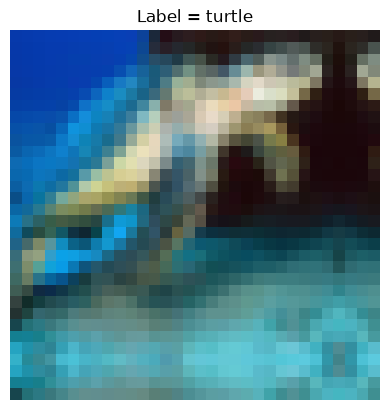

In [13]:
x = random.randint(0, 100)

d, t = train_ds[x]
visualize_tensor_data(d, t)

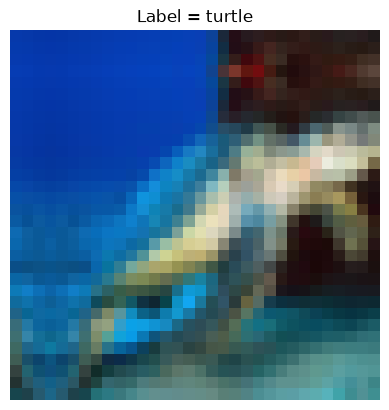

In [14]:
x = random.randint(0, 100)

d, t = train_ds[x]
visualize_tensor_data(d, t)

19
29
0
11
1
86
90
28
23
31
39
96
82
17
71
39
8
97
80
71
74
59
70
87
59
84
64
52
42
64
8
17
47
65
21
22
81
11
24
84
78
45
49
97
56
76
11
90
89
78
73
14
87
9
71
6
47
20
98
47
36
55
72
43
51
35
83
33
27
53
92
50
15
89
36
18
89
46
33
42
39
64
75
38
23
42
66
77
49
18
46
15
35
69
95
83
75
99
73
93


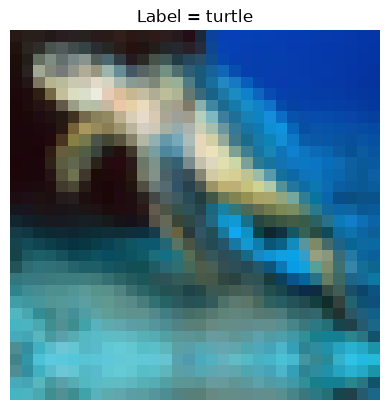

In [15]:
for x in range(100):
    d, t = train_ds[x]
    print(t)
    visualize_tensor_data(d, t)

TypeError: unsupported operand type(s) for /: 'Tensor' and 'str'

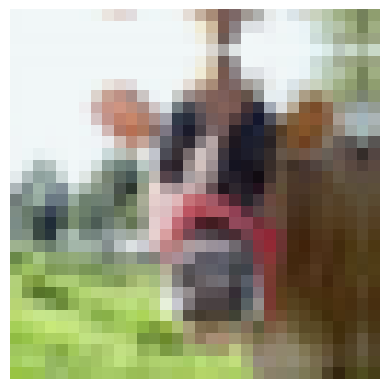

In [16]:
import seaborn as sns

for x in range(100):
    data, label = train_ds[x]
    data = data.permute(1, 2, 0)
    # Un-normalize
    data = data * torch.as_tensor([0.2470, 0.2435, 0.2616]) + torch.as_tensor(
        [
            0.4914,
            0.4822,
            0.4465,
        ]  #         mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]
    )
    plt.imshow(data)
    plt.axis("off")
    plt.savefig(f"{data/class_names[label]}.png")
    plt.title(f"Label = {class_names[label]}")
plt.show()

In [17]:
len(train_ds)

50000

In [18]:
import copy

train_ds_full = copy.deepcopy(train_ds)

In [19]:
train_ds.data = train_ds.data[:20000]

In [20]:
len(train_ds)

20000

In [21]:
len(train_ds_full)

50000

In [25]:
d = train_ds.data[0]

(32, 32, 3)

## cnn

In [28]:
def make_mlp(
    num_inputs: int, num_outputs: int, activation: Any = None, hidden_sizes: int = [128]
) -> nn.Module:

    if activation == "relu":
        act_cls = nn.ReLU
    elif activation == "tanh":
        act_cls = nn.Tanh
    elif activation == "none" or not activation:
        act_cls = nn.Identity
    else:
        raise ValueError(f"Unexpected activation={repr(activation)}")

    net = [nn.Flatten(), nn.Linear(num_inputs, hidden_sizes[0]), act_cls()]

    for i in range(1, len(hidden_sizes)):
        net.extend([nn.Linear(hidden_sizes[i - 1], hidden_sizes[i]), act_cls()])

    net.extend([nn.Linear(hidden_sizes[-1], num_outputs)])

    return nn.Sequential(*net)

In [29]:
def make_cnn(
    num_outputs: int,
    activation: Any = None,
    num_conv_layers: int = 4,
    num_fc_layers: int = 2,
) -> nn.Module:
    r"""
    Returns a PyTorch module representing a CNN network that takes in image-like input with shape [3, 32, 32].

    Args:
        num_outputs (int): size of the final output layer. E.g., if the network is a classifier, this is usually #classes.
        activation (str): activation functions between conv/linear layers. Supported choices are ['relu', 'tanh', 'none'] (always strings).
            For 'none', no activation function is applied, and the previous conv/linear output is directly fed into the next conv/linear.
        num_conv_layers (int): number of conv layers in CNN. This should be >= 3 and <= 5.
            First conv layer should always use 5x5 kernels, mapping 3-channel data to 12-channel data, with **reflect** padding=2 and no striding.
            Subsequent conv layers should always use 3x3 kernels, mapping to 64-channel data, with zeros (default) padding=1 and strides=2.
        num_fc_layers (int): number of fc/linear layers after the convolutional part. This should be >= 2.
            For all but the last fc layer, it should output 128-dimensional vectors.

    Returns:
        (nn.Module) The CNN network of desired structure.

    If an unexpected input is given, this will raise a ValueError. (You can assume that arguments are of correct types.)
    """
    if activation == "relu":
        act_cls = nn.ReLU
    elif activation == "tanh":
        act_cls = nn.Tanh
    elif activation == "none" or not activation:
        act_cls = nn.Identity
    else:
        raise ValueError(f"Unexpected activation={repr(activation)}")

    net = [
        nn.Linear(),
        nn.Conv2d(in_channels=3, out_channels=12, kernel_size=(5, 5), padding=2),
    ]
    for i in range(num_conv_layers - 1):
        net.extend(
            [
                nn.Conv2d(
                    in_channels=0, out_channels=64, kernel_size=3, padding=1, stride=2
                )
            ]
        )
    for i in range(num_fc_layers - 1):
        net.extend([nn.Linear(64, 128), act_cls()])
    net.extend([nn.Linear(128, num_outputs)])

    return nn.Sequential(*net)

In [30]:
print(make_cnn(100, "tanh", num_conv_layers=5, num_fc_layers=4))

Sequential(
  (0): Conv2d(3, 12, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): Conv2d(0, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (2): Conv2d(0, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (3): Conv2d(0, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (4): Conv2d(0, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (5): Linear(in_features=64, out_features=128, bias=True)
  (6): Tanh()
  (7): Linear(in_features=64, out_features=128, bias=True)
  (8): Tanh()
  (9): Linear(in_features=64, out_features=128, bias=True)
  (10): Tanh()
  (11): Linear(in_features=128, out_features=100, bias=True)
)


/Users/deven/.virtualenvs/Machine_Learning_Algorithms/lib/python3.12/site-packages/torch/nn/modules/conv.py:196: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


In [41]:
# def make_nn( num_inputs: int, num_outputs: int, activation: Any = None, hidden_sizes: int = [128])

In [42]:
32 * 32 == 1024

True

In [43]:
print("num_outputs=100, tanh, hidden_sizes=[128, 120]")
print(make_mlp(10, 100, "tanh", hidden_sizes=[128, 120]))

num_outputs=100, tanh, hidden_sizes=[128, 120]
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=10, out_features=128, bias=True)
  (2): Tanh()
  (3): Linear(in_features=128, out_features=120, bias=True)
  (4): Tanh()
  (5): Linear(in_features=120, out_features=100, bias=True)
)


In [44]:
print("num_outputs=100, tanh, num_conv_layers=5, num_fc_layers=4:")
print(make_cnn(100, "tanh", num_conv_layers=5, num_fc_layers=4))
print()

num_outputs=100, tanh, num_conv_layers=5, num_fc_layers=4:
Sequential(
  (0): Conv2d(3, 12, kernel_size=(5, 5), stride=(0, 0), padding=(2, 2))
  (1): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (2): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (3): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (4): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (5): Linear(in_features=64, out_features=128, bias=True)
  (6): Tanh()
  (7): Linear(in_features=64, out_features=128, bias=True)
  (8): Tanh()
  (9): Linear(in_features=64, out_features=128, bias=True)
  (10): Tanh()
  (11): Linear(in_features=128, out_features=100, bias=True)
)



In [45]:
print("num_outputs=100, tanh, hidden_sizes=[128, 120]")
print(make_mlp(10, 100, "tanh", hidden_sizes=[128, 120]))
print()
print("num_outputs=100, tanh, num_conv_layers=5, num_fc_layers=4:")
print(make_cnn(100, "tanh", num_conv_layers=5, num_fc_layers=4))
print()
print("num_outputs=3, no activation, num_conv_layers=3, num_fc_layers=2:")
print(make_cnn(3, "none", num_conv_layers=3, num_fc_layers=2))

num_outputs=100, tanh, hidden_sizes=[128, 120]
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=10, out_features=128, bias=True)
  (2): Tanh()
  (3): Linear(in_features=128, out_features=120, bias=True)
  (4): Tanh()
  (5): Linear(in_features=120, out_features=100, bias=True)
)

num_outputs=100, tanh, num_conv_layers=5, num_fc_layers=4:
Sequential(
  (0): Conv2d(3, 12, kernel_size=(5, 5), stride=(0, 0), padding=(2, 2))
  (1): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (2): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (3): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (4): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (5): Linear(in_features=64, out_features=128, bias=True)
  (6): Tanh()
  (7): Linear(in_features=64, out_features=128, bias=True)
  (8): Tanh()
  (9): Linear(in_features=64, out_features=128, bias=True)
  (10): Tanh()
  (11): Linear(in_features=128, out_feat

## Training loop

**Question 6**: Implement the following training and evaluate functions according to docstring. Complete the `FIXME`s in `train_epoch`, `evaluate`, and `train`. Attach your code to PDF.

---

Links you may find useful:
+ Classification loss: https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html?highlight=cross_entropy#torch.nn.functional.cross_entropy
+ Learning rate adjustment: https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate

(You are not required to use these classes)

In [82]:
d, t = train_ds[0]

In [83]:
d.shape

torch.Size([3, 32, 32])

In [31]:
@dataclasses.dataclass
class EvaluateResult:
    r"""
    A collection containing everything we need to know about the evaluate results.

    See `evaluate` docstring for meanings of the members of this class
    """

    acc: float  # overall accuracy
    correct_predictions: torch.Tensor  # size |dataset|
    confidence: torch.Tensor  # size |dataset|

In [32]:
device

device(type='mps')

In [33]:
def train_epoch(
    epoch: int,
    model: nn.Module,
    train_loader: torch.utils.data.DataLoader,
    optim: torch.optim.Optimizer,
):
    # Set model to training mode
    model.train()

    # Define the cross-entropy loss function
    criterion = nn.CrossEntropyLoss()

    loss_values = []

    # Iterate over the training dataset batches
    for batched_images, batched_target_class_indices in tqdm(
        train_loader, desc=f"Training @ epoch {epoch}"
    ):
        # Clear previously computed gradients
        batched_images = batched_images.to(device)
        batched_target_class_indices = batched_target_class_indices.to(device)
        optim.zero_grad()

        # Forward pass: compute predicted outputs by passing inputs to the model
        outputs = model(batched_images)

        # Calculate the batch loss
        loss = criterion(outputs, batched_target_class_indices)

        # Backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()

        # Parameter update: perform a single optimization step
        optim.step()

        # Append the loss value as a standard Python float
        loss_values.append(loss.item())

    return loss_values

In [34]:
async def factorial(n):
    return 1 if n < 2 else n * await factorial(n - 1)

In [35]:
await factorial(10)

3628800

In [36]:
import asyncio
import nest_asyncio2

nest_asyncio2.apply()

In [37]:
import os
import importlib

env = os.environ

In [38]:
@dataclasses.dataclass
class TrainResult:
    r"""
    A collection containing everything we need to know about the training results
    """

    num_epochs: int

    # Training loss (saved at each iteration in `train_epoch`)
    train_losses: List[float]

    # The epochs where we perform evaluation
    eval_epochs: List[int]

    # Training accuracies, computed at each epoch in `eval_epochs`
    train_accs: List[float]

    # Validation accuracies, computed at each epoch in `eval_epochs`
    val_accs: List[float]

    # The last validation evaluation full result
    final_val_eval_result: EvaluateResult = None

In [39]:
@torch.no_grad()
def evaluate(model: nn.Module, loader: torch.utils.data.DataLoader) -> EvaluateResult:
    r"""
    Evaluate a classifier `model` on dataset contained in `loader`.

    For each input, the predicted label is taken as one with highest probability in the distribution given by `model`.

    In addition to compute overall accuracies, we also output
        (1) a boolean Tensor with size |dataset|, showing whether each sample is correctly classified.
        (2) a float32 Tensor with size |dataset|, showing the `model`'s assigned probability for its prediction, called *confidence*.

    Args:
        model (nn.Module): our network (created using `make_cnn`).
        loader (DataLoader): a DataLoader that yields (batched_images, batched_target_class_indices) when iterated.

    Returns:
        (EvaluateResult) Containing overall accuracy, whether each sample is correctly classified, and confidence.
            The tensors should be on **CPU**.
    """
    # FIXME
    model.eval()
    result = EvaluateResult(
        acc=0,
        correct_predictions=torch.tensor(0, device=device),
        confidence=torch.tensor(0, device=device),
    )
    total = 0
    for data, target in loader:

        data = data.to(device)
        # print(data.shape)
        target = target.to(device)
        # Update `correct_predictions`.
        # Make sure that you add a *Python number*, not a *PyTorch scalar*.
        # Remember that you can use `pytorch_scalar.item()` to get its content
        # as a Python number.
        # FIXME
        logits = model(data)
        print(logits.device)
        result.confidence = torch.softmax(logits, dim=1)
        total += target.size(0)
        _, output = torch.max(result.confidence, 1)
        # printt((output==target).sum().item())
        # print(pred.argmax(1)
        result.correct_predictions += (output == target).sum().item()
    # losses = total - correct_predictions
    result.acc = float(result.correct_predictions) / total
    return result

In [238]:
# def train_epoch(epoch: int, model: nn.Module, train_loader: torch.utils.data.DataLoader, optim: torch.optim.Optimizer):
#     r"""
#     Trains `model` on `train_loader` for cross entropy loss for one epoch.
#
#     Args:
#         epoch (int): the current epoch number (i.e., number of epochs done before this one).
#         model (nn.Module): our network (created using `make_cnn`).
#         train_loader (DataLoader): a DataLoader that yields (batched_images, batched_target_class_indices) when iterated.
#         optim (Optimizer): optimizer object that is created with `model` parameters and should be used for updating `model` in this function.
#
#     Returns:
#         (List[float]) the losses computed at each iteration as a list of *Python* numbers.
#
#     NOTE:
#       + Remember to clear previously computed gradient at beginning of each iteration.
#       + Convert loss values to python floats (e.g., via `.item()`) before adding to `loss_values`.
#     """
#     loss_values: List[float] = []
#
#     for data, target in tqdm(train_loader, desc=f'Training @ epoch {epoch}'):
#         # FIXME
#         pass
#
#     return loss_values
#
#
#
# @dataclasses.dataclass
# class EvaluateResult:
#     r"""
#     A collection containing everything we need to know about the evaluate results.
#
#     See `evaluate` docstring for meanings of the members of this class
#     """
#     acc: float  # overall accuracy
#     correct_predictions: torch.Tensor  # size |dataset|
#     confidence: torch.Tensor  # size |dataset|
#
#
# @torch.no_grad()
# def evaluate(model: nn.Module, loader: torch.utils.data.DataLoader) -> EvaluateResult:
#     r"""
#     Evaluate a classifier `model` on dataset contained in `loader`.
#
#     For each input, the predicted label is taken as one with highest probability in the distribution given by `model`.
#
#     In addition to compute overall accuracies, we also output
#         (1) a boolean Tensor with size |dataset|, showing whether each sample is correctly classified.
#         (2) a float32 Tensor with size |dataset|, showing the `model`'s assigned probability for its prediction, called *confidence*.
#
#     Args:
#         model (nn.Module): our network (created using `make_cnn`).
#         loader (DataLoader): a DataLoader that yields (batched_images, batched_target_class_indices) when iterated.
#
#     Returns:
#         (EvaluateResult) Containing overall accuracy, whether each sample is correctly classified, and confidence.
#             The tensors should be on **CPU**.
#     """
#     # FIXME
#     pass
#
#
# @dataclasses.dataclass
# class TrainResult:
#     r"""
#     A collection containing everything we need to know about the training results
#     """
#     num_epochs: int
#
#     # Training loss (saved at each iteration in `train_epoch`)
#     train_losses: List[float]
#
#     # The epochs where we perform evaluation
#     eval_epochs: List[int]
#
#     # Training accuracies, computed at each epoch in `eval_epochs`
#     train_accs: List[float]
#
#     # Validation accuracies, computed at each epoch in `eval_epochs`
#     val_accs: List[float]
#
#     # The last validation evaluation full result
#     final_val_eval_result: EvaluateResult = None
#
#
# def train(model: nn.Module, train_set, val_set, *, num_epochs=60, lr=0.003, train_epoch_fn=train_epoch, **kwargs):
#     r"""
#     Train `model` on `train_set` for `num_epochs` epochs using **Adam** optimizer and `lr` learning rate
#     following a decay schedule by a factor of `0.3` at epochs `[5, 50]`.
#
#     Args:
#         model (nn.Module): our network (created using `make_cnn`).
#         train_set (Dataset): CIFAR-100 training dataset.
#         val_set (Dataset): CIFAR-100 validation dataset. Evaluated every *5* epochs and at the end of training.
#         num_epochs (int): number of total training epochs.
#         lr (float): initial learning rate.
#         train_epoch_fn (Callable): function that trains the model for a single epoch. This is `train_epoch`
#             usually, but we will use different choices in later questions.
#
#     Returns:
#         (TrainResult)
#     """
#     # Data loaders
#     train_loader = torch.utils.data.DataLoader(train_set, batch_size=512, shuffle=True)  # Random order for training ("[S]tochastic" in SGD)
#     val_loader = torch.utils.data.DataLoader(val_set, batch_size=1024, shuffle=False)
#
#     # Our classifier
#     print('Model =', model)
#
#     # Create optimizer and lr scheduler
#     # FIXME
#     optim = '?????'
#     scheduler = '?????'
#
#     result: TrainResult = TrainResult(num_epochs, train_losses=[], eval_epochs=[], train_accs=[], val_accs=[])
#     last_eval_epoch = -float('inf')
#
#     # Iterate through the entire training dataset `num_epochs` times
#     for epoch in range(num_epochs):
#         if epoch - last_eval_epoch >= 5:
#             result.eval_epochs.append(epoch)
#             result.train_accs.append(evaluate(model, train_loader).acc)
#             result.val_accs.append(evaluate(model, val_loader).acc)
#             print(f"Epoch = {epoch:> 2d}    Train acc = {result.train_accs[-1]:.2%}    Val acc = {result.val_accs[-1]:.2%}")
#             last_eval_epoch = epoch
#         # Train over the entire `train_set` with given `train_epoch_fn` function (i.e., one epoch)
#         result.train_losses.extend(train_epoch_fn(epoch, model, train_loader, optim, **kwargs))
#         # Evaluate with our `evaluate` function
#         print(f"Epoch = {epoch:> 2d}    Train loss = {result.train_losses[-1]:.4f}")
#
#         # Adjust learning rate if needed
#         scheduler.step()
#
#     result.eval_epochs.append(num_epochs)
#     result.train_accs.append(evaluate(model, train_loader).acc)
#     result.final_val_eval_result = evaluate(model, val_loader)
#     result.val_accs.append(result.final_val_eval_result.acc)
#     print(f"Epoch = {num_epochs:> 2d}    Train acc = {result.train_accs[-1]:.2%}    Val acc = {result.val_accs[-1]:.2%}")
#
#     return result

In [26]:
d.shape

torch.Size([3, 32, 32])

In [40]:
logit = torch.tensor([[0.3, 0.5, 0.7]])
torch.softmax(logit, dim=1)

tensor([[0.2693, 0.3289, 0.4018]])

In [240]:
x, output = torch.max(logit, 1)
display(x)
output

tensor([0.7000])

tensor([2])

In [241]:
output

tensor([2])

In [41]:
train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=512, shuffle=True, pin_memory=True
)
val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=1024, shuffle=False, pin_memory=True
)

In [42]:
x, t = next(iter(train_loader))

/Users/deven/.virtualenvs/Machine_Learning_Algorithms/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [43]:
x.device

device(type='cpu')

In [44]:
x.shape

torch.Size([512, 3, 32, 32])

In [33]:
t.shape

torch.Size([512])

In [31]:
d.shape

torch.Size([3, 32, 32])

In [45]:
def train(
    model: nn.Module,
    train_set,
    val_set,
    *,
    num_epochs=60,
    lr=0.003,
    train_epoch_fn=train_epoch,
    **kwargs,
):
    r"""
    Train `model` on `train_set` for `num_epochs` epochs using **Adam** optimizer and `lr` learning rate
    following a decay schedule by a factor of `0.3` at epochs `[5, 50]`.

    Args:
        model (nn.Module): our network (created using `make_cnn`).
        train_set (Dataset): CIFAR-100 training dataset.
        val_set (Dataset): CIFAR-100 validation dataset. Evaluated every *5* epochs and at the end of training.
        num_epochs (int): number of total training epochs.
        lr (float): initial learning rate.
        train_epoch_fn (Callable): function that trains the model for a single epoch. This is `train_epoch`
            usually, but we will use different choices in later questions.

    Returns:
        (TrainResult)
    """
    # Data loaders
    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=512, shuffle=True
    )  # Random order for training ("[S]tochastic" in SGD)
    val_loader = torch.utils.data.DataLoader(val_set, batch_size=1024, shuffle=False)

    # Our classifier
    print("Model =", model)

    # Create optimizer and lr scheduler
    # FIXME
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.3)
    scheduler = torch.optim.lr_scheduler.LinearLR(
        optim, start_factor=0.5, end_factor=1, total_iters=100
    )

    result: TrainResult = TrainResult(
        num_epochs, train_losses=[], eval_epochs=[], train_accs=[], val_accs=[]
    )
    last_eval_epoch = -float("inf")

    # Iterate through the entire training dataset `num_epochs` times
    for epoch in range(num_epochs):
        if epoch - last_eval_epoch >= 5:
            result.eval_epochs.append(epoch)
            result.train_accs.append(evaluate(model, train_loader).acc)
            result.val_accs.append(evaluate(model, val_loader).acc)
            print(
                f"Epoch = {epoch:> 2d}    Train acc = {result.train_accs[-1]:.2%}    Val acc = {result.val_accs[-1]:.2%}"
            )
            last_eval_epoch = epoch
        # Train over the entire `train_set` with given `train_epoch_fn` function (i.e., one epoch)
        result.train_losses.extend(
            train_epoch_fn(epoch, model, train_loader, optim, **kwargs)
        )
        # Evaluate with our `evaluate` function
        print(f"Epoch = {epoch:> 2d}    Train loss = {result.train_losses[-1]:.4f}")

        # Adjust learning rate if needed
        scheduler.step()

    result.eval_epochs.append(num_epochs)
    result.train_accs.append(evaluate(model, train_loader).acc)
    result.final_val_eval_result = evaluate(model, val_loader)
    result.val_accs.append(result.final_val_eval_result.acc)
    print(
        f"Epoch = {num_epochs:> 2d}    Train acc = {result.train_accs[-1]:.2%}    Val acc = {result.val_accs[-1]:.2%}"
    )

    return result

In [46]:
model = make_mlp(3072, 100, activation="tanh", hidden_sizes=[512, 128])
model = model.to(device)

In [ ]:
result = train(model, train_ds, val_ds, num_epochs=60, lr=0.003)

In [248]:
result.final_val_eval_result

EvaluateResult(acc=0.1895, correct_predictions=tensor(1895, device='mps:0'), confidence=tensor([[0.0039, 0.0443, 0.0053,  ..., 0.0091, 0.0092, 0.0084],
        [0.0059, 0.0040, 0.0444,  ..., 0.0094, 0.0066, 0.0294],
        [0.0002, 0.0018, 0.0027,  ..., 0.0156, 0.0022, 0.0226],
        ...,
        [0.0013, 0.0352, 0.0003,  ..., 0.0028, 0.0014, 0.0148],
        [0.0006, 0.0028, 0.0039,  ..., 0.0131, 0.0116, 0.0193],
        [0.0764, 0.0813, 0.0125,  ..., 0.0018, 0.0136, 0.0054]],
       device='mps:0'))

In [249]:
len(result.train_losses)

2400

We provide the following learning curve plotting function (similar to homework 1).

In [250]:
def learning_curve(result: TrainResult, *, title: str = "Learning Curve"):
    r"""
    Plot the training loss, training accuracy, and validation accuracy versus
    epochs taken.
    """
    fig, ax_loss = plt.subplots(figsize=(8, 5))
    ax_loss.set_title(title, fontsize=16)
    ax_loss.set_xlabel("Epoch", fontsize=12)

    l_trloss = ax_loss.plot(
        torch.arange(len(result.train_losses))
        / len(result.train_losses)
        * result.num_epochs,
        result.train_losses,
        label="Train loss",
        color="C0",
    )
    ax_loss.set_ylim(0, 4.8)
    ax_loss.set_ylabel("Train loss", color="C0", fontsize=12)
    ax_loss.tick_params(axis="y", labelcolor="C0")

    ax_acc = ax_loss.twinx()
    l_tracc = ax_acc.plot(
        result.eval_epochs,
        result.train_accs,
        label="Train acc",
        color="C1",
        linestyle="--",
    )
    if len(result.val_accs):
        l_valacc = ax_acc.plot(
            result.eval_epochs, result.val_accs, label="Val acc", color="C1"
        )
    else:
        l_valacc = []
    ax_acc.set_ylim(0, 1)
    ax_acc.set_ylabel("Accuracies", color="C1", fontsize=12)
    ax_acc.tick_params(axis="y", labelcolor="C1")

    lines = l_trloss + l_tracc + l_valacc
    ax_loss.legend(lines, [l.get_label() for l in lines], loc="upper left", fontsize=13)

In [251]:
width = 128
depth = 3
model = make_mlp(3072, 100, activation="relu", hidden_sizes=[width, depth]).to(device)
result = train(
    model, train_ds, val_ds, num_epochs=60, lr=0.003, train_epoch_fn=train_epoch
)
# Create a MLP 128 width, 3 depth on the GPU, train it, and plot learning curves.

Model = Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=128, bias=True)
  (2): Tanh()
  (3): Linear(in_features=128, out_features=3, bias=True)
  (4): Tanh()
  (5): Linear(in_features=3, out_features=100, bias=True)
)
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
Epoch =  0    Train acc = 1.22%    Val acc = 1.42%


Training @ epoch 0:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch =  0    Train loss = 4.7544


Training @ epoch 1:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch =  1    Train loss = 4.5644


...

Epoch =  57    Train loss = 4.0752


Training @ epoch 58:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch =  58    Train loss = 3.9937


Training @ epoch 59:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch =  59    Train loss = 4.2657
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
mps:0
Epoch =  60    Train acc = 5.79%    Val acc = 5.53%


In [165]:
mlp

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=32, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=3, bias=True)
  (4): ReLU()
  (5): Linear(in_features=3, out_features=100, bias=True)
)

In [49]:
def make_cnn(
    num_outputs: int,
    activation: Any = None,
    num_conv_layers: int = 4,
    num_fc_layers: int = 2,
) -> nn.Module:
    r"""
    Returns a PyTorch module representing a CNN network that takes in image-like input with shape [3, 32, 32].

    Args:
        num_outputs (int): size of the final output layer. E.g., if the network is a classifier, this is usually #classes.
        activation (str): activation functions between conv/linear layers. Supported choices are ['relu', 'tanh', 'none'] (always strings).
            For 'none', no activation function is applied, and the previous conv/linear output is directly fed into the next conv/linear.
        num_conv_layers (int): number of conv layers in CNN. This should be >= 3 and <= 5.
            First conv layer should always use 5x5 kernels, mapping 3-channel data to 12-channel data, with **reflect** padding=2 and no striding.
            Subsequent conv layers should always use 3x3 kernels, mapping to 64-channel data, with zeros (default) padding=1 and strides=2.
        num_fc_layers (int): number of fc/linear layers after the convolutional part. This should be >= 2.
            For all but the last fc layer, it should output 128-dimensional vectors.

    Returns:
        (nn.Module) The CNN network of desired tructure.

    If an unexpected input is given, this will raise a ValueError. (You can assume that arguments are of correct types.)
    """
    if activation == "relu":
        act_cls = nn.ReLU
    elif activation == "tanh":
        act_cls = nn.Tanh
    elif activation == "none" or not activation:
        act_cls = nn.Identity
    else:
        raise ValueError(f"Unexpected activation={repr(activation)}")

    net = [nn.Conv2d(in_channels=0, out_channels=12, kernel_size=(5, 5), padding=2)]
    for i in range(num_conv_layers - 1):
        net.extend(
            [
                nn.Conv2d(
                    in_channels=0, out_channels=64, kernel_size=3, padding=1, stride=2
                )
            ]
        )
    for i in range(num_fc_layers - 1):
        net.extend([nn.Linear(64, 128), act_cls()])
    net.extend([nn.Linear(128, num_outputs)])

    return nn.Sequential(*net)

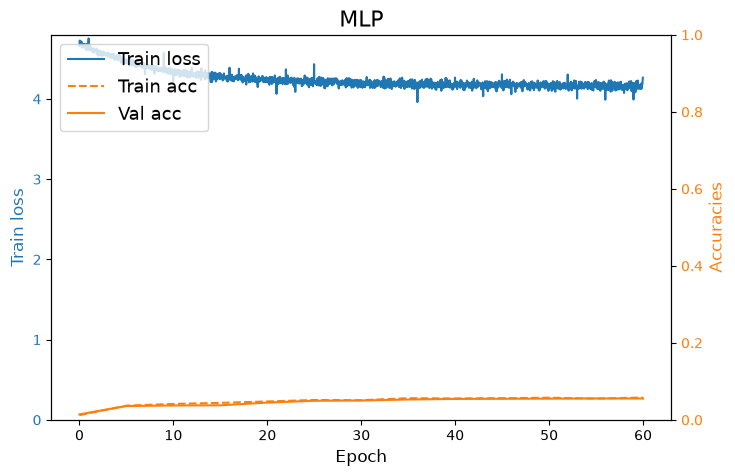

In [252]:
# Create a MLP 128 width, 3 depth on the GPU, train it, and plot learning curves.
learning_curve(result, title="MLP")

In [ ]:
# Create a MLP 128 width, 7 depth on the GPU, train it, and plot learning curves.

In [50]:
# Create a CNN 4 convolutional layers, 3 MLP layers on the GPU, train it, and plot learning curves.
cnn = make_cnn(100, activation="tanh", num_conv_layers=4, num_fc_layers=3)
cnn = cnn.to(device)
result = train(cnn, train_ds, val_ds, num_epochs=60)
# learning_curve(result, "cnn")

Model = Sequential(
  (0): Conv2d(0, 12, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): Conv2d(0, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (2): Conv2d(0, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (3): Conv2d(0, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (4): Linear(in_features=64, out_features=128, bias=True)
  (5): Tanh()
  (6): Linear(in_features=64, out_features=128, bias=True)
  (7): Tanh()
  (8): Linear(in_features=128, out_features=100, bias=True)
)


RuntimeError: Given groups=1, weight of size [12, 0, 5, 5], expected input[512, 3, 32, 32] to have 0 channels, but got 3 channels instead

In [ ]:
def make_cnn(
    num_outputs: int,
    activation: Any = None,
    num_conv_layers: int = 4,
    num_fc_layers: int = 2,
) -> nn.Module:
    r"""
    Returns a PyTorch module representing a CNN network that takes in image-like input with shape [3, 32, 32].

    Args:
        num_outputs (int): size of the final output layer. E.g., if the network is a classifier, this is usually #classes.
        activation (str): activation functions between conv/linear layers. Supported choices are ['relu', 'tanh', 'none'] (always strings).
            For 'none', no activation function is applied, and the previous conv/linear output is directly fed into the next conv/linear.
        num_conv_layers (int): number of conv layers in CNN. This should be >= 3 and <= 5.
            First conv layer should always use 5x5 kernels, mapping 3-channel data to 12-channel data, with **reflect** padding=2 and no striding.
            Subsequent conv layers should always use 3x3 kernels, mapping to 64-channel data, with zeros (default) padding=1 and strides=2.
        num_fc_layers (int): number of fc/linear layers after the convolutional part. This should be >= 2.
            For all but the last fc layer, it should output 128-dimensional vectors.

    Returns:
        (nn.Module) The CNN network of desired tructure.

    If an unexpected input is given, this will raise a ValueError. (You can assume that arguments are of correct types.)
    """
    if activation == "relu":
        act_cls = nn.ReLU
    elif activation == "tanh":
        act_cls = nn.Tanh
    elif activation == "none" or not activation:
        act_cls = nn.Identity
    else:
        raise ValueError(f"Unexpected activation={repr(activation)}")

    net = [nn.Conv2d(in_channels=3, out_channels=12, kernel_size=(5, 5), padding=2)]
    for i in range(num_conv_layers - 1):
        net.extend(
            [
                nn.Conv2d(
                    in_channels=0, out_channels=64, kernel_size=3, padding=1, stride=2
                )
            ]
        )
    for i in range(num_fc_layers - 1):
        net.extend([nn.Linear(64, 128), act_cls()])
    net.extend([nn.Linear(128, num_outputs)])

    return nn.Sequential(*net)

In [256]:
xm = nn.Conv2d(16, 33, (3, 5), stride=(2, 1), padding=(4, 2))

In [274]:
m1 = nn.Conv2d(in_channels=16, out_channels=33, kernel_size=3, stride=2)

In [267]:
torch.randn_like(torch.arange(1, 6), dtype=torch.float32)

tensor([-1.2108,  0.1739, -0.4701, -2.1022, -0.4177])

In [285]:
input = torch.randn(16, 16, 32)

In [286]:
input

tensor([[[ 0.0836, -0.9041,  0.5244,  ...,  0.1943, -0.5208, -0.7965],
         [ 0.2233,  1.4947,  0.9227,  ..., -0.1559, -0.6888, -0.5309],
         [-1.1328, -0.3400,  0.7002,  ..., -1.7898, -0.2904,  1.4436],
         ...,
         [ 0.8175, -0.4081,  0.2596,  ..., -1.1144, -1.4524, -1.0913],
         [-0.2836,  1.6438, -2.3078,  ...,  1.7863, -0.1651, -0.2353],
         [-0.3249, -0.3349, -0.8275,  ...,  0.1914,  1.6134, -1.0846]],

        [[-2.6466,  0.8322,  0.7263,  ...,  0.0198,  1.3270, -0.6659],
         [-0.2392, -0.7288, -1.4659,  ...,  0.0795, -0.0307,  0.1203],
         [-0.7069,  0.4600, -1.1603,  ..., -2.0258,  0.9462, -0.2125],
         ...,
         [ 0.3192,  1.5421, -0.5879,  ..., -0.0558, -1.3185,  0.1502],
         [ 0.0590,  0.6373, -0.0660,  ...,  0.1471,  2.1152, -0.7439],
         [-1.5268,  0.5550,  0.8097,  ...,  0.0975, -2.5440,  0.1300]],

        [[ 1.0029,  0.7458, -0.9666,  ...,  0.0228,  1.3288,  0.2858],
         [-1.0007, -0.1020,  0.1144,  ..., -0

In [287]:
m1(input)

tensor([[[ 3.5724e-01, -3.9032e-01, -2.3004e-01,  ...,  7.3144e-01,
          -2.4805e-01,  3.4010e-01],
         [ 6.6862e-01, -7.0793e-01,  3.8817e-01,  ..., -2.7618e-01,
           4.8405e-01, -5.6544e-01],
         [-2.3079e-01,  7.0395e-01,  2.7341e-01,  ...,  4.5601e-01,
           1.8240e-01,  2.1114e-01],
         ...,
         [ 1.4043e+00,  1.3665e+00, -3.3662e-02,  ..., -7.6159e-01,
          -5.7383e-01,  1.2127e-01],
         [-8.7327e-01, -2.9380e-01, -8.0811e-01,  ...,  1.6450e-01,
           3.0924e-01, -8.2010e-01],
         [ 2.7672e-01, -9.6939e-02, -1.6160e-01,  ..., -7.7192e-01,
           6.3113e-01, -6.7892e-02]],

        [[ 1.5908e-01, -3.9682e-01,  5.6420e-01,  ..., -9.8802e-02,
           6.6089e-01, -4.1904e-01],
         [-5.9238e-01, -1.7551e-01, -1.6185e-01,  ..., -5.0500e-02,
           4.8368e-01, -3.7699e-02],
         [-5.2885e-01, -6.5666e-01, -3.0968e-01,  ...,  1.0859e-01,
          -5.3778e-02,  4.1848e-02],
         ...,
         [ 4.5071e-01,  4